# picosmh final benchmark report

POSIX SHM SPSC ring — smoke/full harness, all backends, GIL vs free-threaded.

See also: [RESULTS.md](./RESULTS.md)


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ART = Path('.')
def j(name):
    p = ART / name
    return json.loads(p.read_text()) if p.exists() else {}



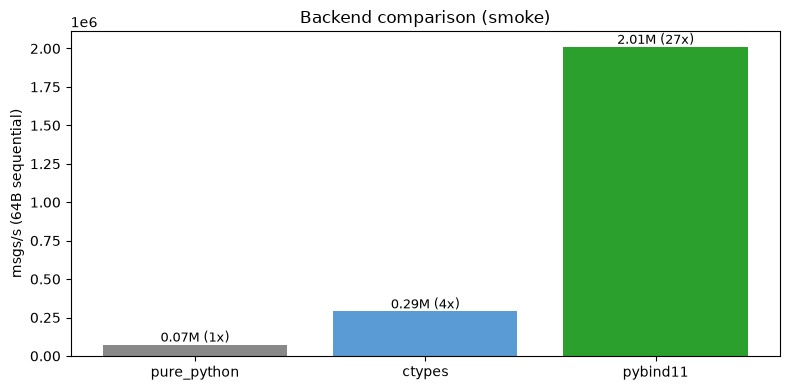

In [2]:
backends = {
    'pure_python': 73849,
    'ctypes': 290030,
    'pybind11': 2010923,
}
pure = backends['pure_python']
labels = list(backends.keys())
vals = [backends[k] for k in labels]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, vals, color=['#888', '#5b9bd5', '#2ca02c'])
ax.set_ylabel('msgs/s (64B sequential)')
ax.set_title('Backend comparison (smoke)')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v/1e6:.2f}M ({v/pure:.0f}x)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()



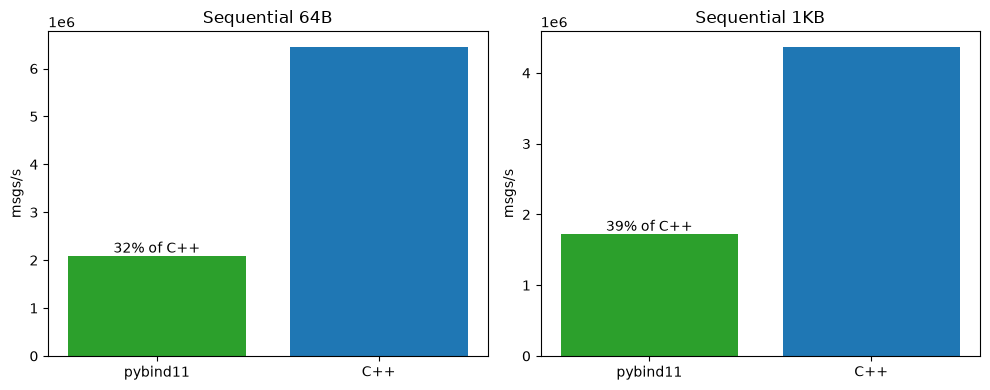

In [3]:
pybind64 = 2087436
cpp64 = 6453897
pybind1k = 1721678
cpp1k = 4369443
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (py, cpp, title) in zip(axes, [(pybind64, cpp64, '64B'), (pybind1k, cpp1k, '1KB')]):
    ax.bar(['pybind11', 'C++'], [py, cpp], color=['#2ca02c', '#1f77b4'])
    ax.set_title(f'Sequential {title}')
    ax.set_ylabel('msgs/s')
    if cpp > 0:
        ax.text(0, py, f'{py/cpp*100:.0f}% of C++', ha='center', va='bottom')
plt.tight_layout()
plt.show()



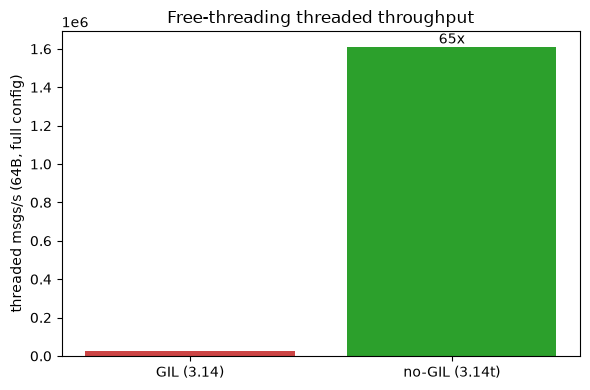

In [4]:
gil_thr = 24857
nogil_thr = 1610788
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['GIL (3.14)', 'no-GIL (3.14t)'], [gil_thr, nogil_thr], color=['#c44', '#2ca02c'])
ax.set_ylabel('threaded msgs/s (64B, full config)')
ax.set_title('Free-threading threaded throughput')
if gil_thr > 0:
    ax.text(1, nogil_thr, f'{nogil_thr/gil_thr:.0f}x', ha='center', va='bottom')
plt.tight_layout()
plt.show()



## Conclusions

- **Default backend:** pybind11 (~2M msgs/s sequential 64B, ~31x vs pure).
- **C++ reference:** ~6.2M msgs/s (64B); pybind ~32-39% of native.
- **Threaded:** python3.14t + free-threaded extension ~**65x** vs GIL.
- **io_uring:** N/A (mmap + futex hot path).
